# Assignment 2

## Part 1: Corpus Construction

In [ ]:
!pip install "numpy<2" -q
!pip install javalang requests pandas tqdm transformers -q
!pip install -r requirements.txt -q


In [ ]:
import subprocess, sys
import os, re, json, random, shutil, subprocess, statistics
from pathlib import Path
from tqdm import tqdm
import requests
import pandas as pd
import javalang
from javalang.tokenizer import tokenize as java_tokenize

random.seed(42)

CLONE_DIR  = "./datasets/java_repos"
OUTPUT_DIR = "./datasets/lstm_dataset"
os.makedirs(CLONE_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_TARGET = 50_000
VAL_SIZE     = 1_000

GITHUB_TOKEN   = ""
NUM_REPOS      = 1650
FILES_PER_REPO = 40
MIN_TOKENS     = 5
MIN_SUM_WORDS  = 3
MAX_SUM_WORDS  = 60

EXCLUDE_DIRS = {
    "test", "tests", "example", "examples",
    "sample", "samples", "demo", "generated", "gen",
}


print(f"  TRAIN_TARGET  : {TRAIN_TARGET:,}")
print(f"  VAL_SIZE      : {VAL_SIZE:,}")
print(f"  NUM_REPOS     : {NUM_REPOS:,}")
print(f"  FILES_PER_REPO: {FILES_PER_REPO}")


In [ ]:
def _headers():
    h = {"Accept": "application/vnd.github+json"}
    if GITHUB_TOKEN:
        h["Authorization"] = f"Bearer {GITHUB_TOKEN}"
    return h


def fetch_java_repos(num_repos: int = 1_200) -> list[dict]:
    buckets = [
        "stars:>10000",
        "stars:3000..10000",
        "stars:1000..3000",
    ]
    repos, seen = [], set()

    for bucket in buckets:
        if len(repos) >= num_repos:
            break
        for page in range(1, 11):
            if len(repos) >= num_repos:
                break
            params = {
                "q"       : f"language:java {bucket} fork:false",
                "sort"    : "stars",
                "order"   : "desc",
                "per_page": 100,
                "page"    : page,
            }
            resp = requests.get(
                "https://api.github.com/search/repositories",
                params=params, headers=_headers(), timeout=30,
            )
            if resp.status_code == 403:
                print(" Rate-limited. Add a GitHub PAT to GITHUB_TOKEN.")
                return repos
            if resp.status_code != 200:
                print(f"  API error {resp.status_code}")
                break
            items = resp.json().get("items", [])
            if not items:
                break
            for item in items:
                if item["full_name"] not in seen:
                    seen.add(item["full_name"])
                    repos.append({
                        "full_name": item["full_name"],
                        "clone_url": item["clone_url"],
                        "stars"    : item["stargazers_count"],
                    })

    return repos[:num_repos]


print("Fetching Java repositories from GitHub…")
repo_list = fetch_java_repos(NUM_REPOS)
df_repos  = pd.DataFrame(repo_list)
print(f"Fetched {len(df_repos):,} repositories")
print()
print("Top 10 by stars:")
print(df_repos[["full_name", "stars"]].head(10).to_string(index=False))

In [ ]:
def clone_repo(clone_url: str, dest: str) -> bool:
    try:
        if os.path.exists(dest):
            return True
        result = subprocess.run(
            ["git", "clone", "--depth", "1", "--quiet", clone_url, dest],
            capture_output=True, text=True, timeout=120,
        )
        return result.returncode == 0
    except Exception:
        return False


cloned, failed = [], []
print(f"Cloning {len(df_repos):,} repos")

for _, row in tqdm(df_repos.iterrows(), total=len(df_repos), desc="Cloning"):
    safe  = row["full_name"].replace("/", "_")
    dest  = os.path.join(CLONE_DIR, safe)
    if clone_repo(row["clone_url"], dest):
        cloned.append({"repo_name": row["full_name"], "local_path": dest})
    else:
        failed.append(row["full_name"])

print(f"\n Cloned : {len(cloned):,}")
print(f"Failed : {len(failed):,}")


In [ ]:
_JAVADOC_RE  = re.compile(r'/\*\*(.*?)\*/', re.DOTALL)
_TAG_LINE    = re.compile(r'^\s*@',         re.MULTILINE)
_HTML_TAG    = re.compile(r'<[^>]+>')
_MULTI_WS    = re.compile(r'\s+')
_GETTER_SET  = re.compile(r'^(get|set|is)[A-Z]')


def extract_javadoc_summary(raw: str) -> str | None:
    """
    Clean a raw Javadoc block and return the first-sentence summary.
    Returns None if the result is empty or too short/long.
    """
    m    = _JAVADOC_RE.search(raw)
    body = m.group(1) if m else raw

    lines = [re.sub(r'^\s*\*+\s?', '', ln) for ln in body.splitlines()]
    body  = '\n'.join(lines)

    tag = _TAG_LINE.search(body)
    if tag:
        body = body[:tag.start()]

    summary = _HTML_TAG.sub(' ', body)
    summary = _MULTI_WS.sub(' ', summary).strip().rstrip('.,:;-').strip().lower()

    if not summary:
        return None
    return summary


def is_getter_setter(method_name: str, body_src: str) -> bool:
    """Heuristic: skip trivial single-statement getters/setters."""
    if not _GETTER_SET.match(method_name):
        return False
    inner = re.sub(r'^[^{]*\{', '', body_src, count=1).strip().rstrip('}')
    return inner.count(';') <= 1


_t = extract_javadoc_summary(
    "/** Returns the absolute value.\n * @param n the number\n * @return result */")
assert _t == "returns the absolute value", repr(_t)
print("Javadoc extractor OK:", repr(_t))


In [ ]:
def read_file(path: str) -> str | None:
    for enc in ('utf-8', 'latin-1', 'cp1252'):
        try:
            return Path(path).read_text(encoding=enc)
        except Exception:
            pass
    return None


def find_java_files(repo_path: str) -> list[str]:
    files = []
    for root, dirs, fnames in os.walk(repo_path):
        dirs[:] = [d for d in dirs if d.lower() not in EXCLUDE_DIRS]
        for f in fnames:
            if f.endswith('.java'):
                files.append(os.path.join(root, f))
    return files


def extract_method_source(lines: list[str], start_1based: int) -> str | None:
    idx, count, started = start_1based - 1, 0, False
    end = idx
    for i in range(idx, len(lines)):
        for ch in lines[i]:
            if ch == '{':
                count += 1; started = True
            elif ch == '}':
                count -= 1
        if started and count == 0:
            end = i; break
    return '\n'.join(lines[idx:end + 1]) if started else None


def find_preceding_javadoc(source: str, method_line: int) -> str | None:
    for m in _JAVADOC_RE.finditer(source):
        end_line = source[:m.end()].count('\n') + 1
        if 0 < method_line - end_line <= 3:
            return m.group(0)
    return None


def count_java_tokens(src: str) -> int:
    try:
        return len(list(java_tokenize(src)))
    except Exception:
        return 0


def extract_pairs_from_file(path: str, repo_name: str) -> list[dict]:
    source = read_file(path)
    if not source:
        return []
    lines = source.splitlines()
    pairs = []
    try:
        tree = javalang.parse.parse(source)
    except Exception:
        return []

    for _, node in tree.filter(javalang.tree.MethodDeclaration):
        if node.position is None:
            continue
        method_src = extract_method_source(lines, node.position.line)
        if not method_src:
            continue
        javadoc = find_preceding_javadoc(source, node.position.line)
        if not javadoc:
            continue
        summary = extract_javadoc_summary(javadoc)
        if not summary:
            continue
        pairs.append({
            "repo"        : repo_name,
            "method_name" : node.name,
            "code"        : method_src,
            "summary"     : summary,
        })
    return pairs

print("Extraction helpers defined.")

In [ ]:
all_pairs     = []
repo_file_log = {}

MINE_TARGET = (TRAIN_TARGET + VAL_SIZE)*1.7

for repo_info in tqdm(cloned, desc="Repos"):
    if len(all_pairs) >= MINE_TARGET:
        tqdm.write(f"Early stop: {len(all_pairs):,} raw pairs collected.")
        break

    rname = repo_info["repo_name"]
    rpath = repo_info["local_path"]

    java_files = find_java_files(rpath)
    if not java_files:
        continue

    if FILES_PER_REPO is None or len(java_files) <= FILES_PER_REPO:
        selected = java_files
    else:
        selected = random.sample(java_files, FILES_PER_REPO)

    repo_pairs = []
    for fpath in selected:
        repo_pairs.extend(extract_pairs_from_file(fpath, rname))

    repo_file_log[rname] = {
        "total_java_files"  : len(java_files),
        "sampled_java_files": len(selected),
        "pairs_extracted"   : len(repo_pairs),
    }
    all_pairs.extend(repo_pairs)

print(f"\nPairs extracted: {len(all_pairs):,}")
print(f"  Repos processed: {len(repo_file_log):,} / {len(cloned):,}")


In [ ]:
def has_non_ascii(text: str) -> bool:
    try:
        text.encode('ascii'); return False
    except UnicodeEncodeError:
        return True


stats = {k: 0 for k in (
    "total", "non_ascii", "too_few_tokens",
    "bad_summary_len", "todo", "empty_body", "kept",
)}

filtered = []

for pair in tqdm(all_pairs, desc="Filtering"):
    stats["total"] += 1
    code, summary = pair["code"], pair["summary"]

    if has_non_ascii(code):
        stats["non_ascii"] += 1; continue

    n_tok = count_java_tokens(code)
    if n_tok < MIN_TOKENS:
        stats["too_few_tokens"] += 1; continue

    n_words = len(summary.split())
    if n_words < MIN_SUM_WORDS or n_words > MAX_SUM_WORDS:
        stats["bad_summary_len"] += 1; continue

    if re.search(r'\b(TODO|FIXME|HACK|XXX)\b', code):
        stats["todo"] += 1; continue

    bm = re.search(r'\{(.*)\}\s*$', code, re.DOTALL)
    if bm and not bm.group(1).strip():
        stats["empty_body"] += 1; continue


    pair["n_tokens"] = n_tok
    filtered.append(pair)
    stats["kept"] += 1

print("Filter results:")
for k, v in stats.items():
    print(f"  {k:<18}: {v:,}")


In [ ]:
def normalise_code(src: str) -> str:
    return re.sub(r'\s+', ' ', src.replace('\n', ' ').replace('\t', ' ')).strip()

for pair in tqdm(filtered, desc="Normalising"):
    pair["code_flat"]    = normalise_code(pair["code"])
    pair["summary_flat"] = re.sub(r'\s+', ' ', pair["summary"]).strip()

print(f"Normalised {len(filtered):,} pairs.")
print("Example:")
ex = filtered[0]
print(f"  code    : {ex['code_flat'][:110]}")
print(f"  summary : {ex['summary_flat']}")


In [ ]:
before = len(filtered)
seen, unique_pairs = set(), []

for p in filtered:
    if p["code_flat"] not in seen:
        seen.add(p["code_flat"])
        unique_pairs.append(p)

print(f"Before dedup : {before:,}")
print(f"After  dedup : {len(unique_pairs):,}")
print(f"Duplicates   : {before - len(unique_pairs):,}")

assert len(unique_pairs) >= TRAIN_TARGET + VAL_SIZE, (
    f"Only {len(unique_pairs):,} unique pairs — need {TRAIN_TARGET + VAL_SIZE:,}. "
    f"Try increasing NUM_REPOS or FILES_PER_REPO."
)

random.shuffle(unique_pairs)


In [ ]:
total       = len(unique_pairs)
val_pairs   = unique_pairs[total - VAL_SIZE : total]
train_pairs = unique_pairs[: TRAIN_TARGET]

print(f"Training pairs   : {len(train_pairs):,}")
print(f"Validation pairs : {len(val_pairs):,}")


In [ ]:
train_code_path    = os.path.join(OUTPUT_DIR, "train_code.txt")
train_summary_path = os.path.join(OUTPUT_DIR, "train_summary.txt")
val_code_path      = os.path.join(OUTPUT_DIR, "val_code.txt")
val_summary_path   = os.path.join(OUTPUT_DIR, "val_summary.txt")

def save_txt_pair(pairs, code_path, summary_path):
    with open(code_path,    'w', encoding='utf-8', errors='replace') as fc, \
         open(summary_path, 'w', encoding='utf-8', errors='replace') as fs:
        for p in pairs:
            fc.write(p['code_flat']    + '\n')
            fs.write(p['summary_flat'] + '\n')

save_txt_pair(train_pairs, train_code_path,    train_summary_path)
save_txt_pair(val_pairs,   val_code_path,      val_summary_path)

print("Files saved:")
for path in [train_code_path, train_summary_path, val_code_path, val_summary_path]:
    n    = sum(1 for _ in open(path, encoding='utf-8'))
    size = os.path.getsize(path) / 1e6
    print(f"{path}")


In [ ]:
train_code_lens    = [len(p['code_flat'].split())    for p in train_pairs]
train_summary_lens = [len(p['summary_flat'].split())  for p in train_pairs]


print("      CORPUS CONSTRUCTION SUMMARY")

print(f"\nData source    : Public GitHub repositories (mined)")
print(f"  Strategy     : GitHub Search API → shallow clone → javalang parse")
print(f"  Repos fetched: {len(df_repos):,}  (stars ≥ 500, non-fork, language:java)")
print(f"  Repos cloned : {len(cloned):,}")
print(f"  Files/repo   : up to {FILES_PER_REPO}")
print(f"\nPair extraction:")
print(f"  Raw pairs    : {stats['total']:,}")
print(f"  After filter : {stats['kept']:,}")
print(f"  After dedup  : {len(unique_pairs):,}")
print(f"\nFinal splits:")
print(f"  Training     : {len(train_pairs):,}")
print(f"  Validation   : {len(val_pairs):,}")
print(f"\nCode stats (whitespace tokens, train):")
print(f"  min    : {min(train_code_lens)}")
print(f"  mean   : {statistics.mean(train_code_lens):.1f}")
print(f"  median : {statistics.median(train_code_lens):.1f}")
print(f"  max    : {max(train_code_lens)}")
print(f"\nSummary stats (words, train):")
print(f"  min    : {min(train_summary_lens)}")
print(f"  mean   : {statistics.mean(train_summary_lens):.1f}")
print(f"  median : {statistics.median(train_summary_lens):.1f}")
print(f"  max    : {max(train_summary_lens)}")
print(f"\nFilters removed:")
for k, v in stats.items():
    if k not in ('total', 'kept'):
        print(f"  {k:<18}: {v:,}")


In [ ]:
metadata = {
    "description": "Java method-to-Javadoc corpus mined from GitHub for LSTM code summarization",
    "data_source": "Public GitHub repositories via GitHub Search API",
    "reference": "CodeXGLUE code-to-text methodology (Lu et al., 2021) — https://github.com/microsoft/CodeXGLUE",
    "mining_strategy": [
        "GitHub Search API: language:java, stars>=500, fork:false, sorted by stars",
        "Four star-range buckets for diversity: >10K, 3K-10K, 1K-3K, 500-1K",
        f"Fetched {len(df_repos):,} repos, cloned {len(cloned):,} with --depth 1",
        f"Sample up to {FILES_PER_REPO} Java files per repo, exclude test/example/demo dirs",
        "Parse with javalang; extract MethodDeclaration nodes with preceding Javadoc",
        "Extract Javadoc first-sentence summary (text before first @tag)",
        f"Filter: non-ASCII, <{MIN_TOKENS} Java tokens, summary <{MIN_SUM_WORDS} or >{MAX_SUM_WORDS} words, TODO/FIXME, getters/setters, empty body",
        "Normalise: flatten code to single whitespace-normalised line; lowercase summary",
        "Deduplicate on exact normalised code string",
        f"Random shuffle; last {VAL_SIZE:,} as validation, first {TRAIN_TARGET:,} as training",
    ],
    "splits": {
        "train"     : len(train_pairs),
        "validation": len(val_pairs),
        "test"      : "1000",
    },
    "filter_stats" : stats,
    "repos_mined"  : repo_file_log,
}

meta_path = os.path.join(OUTPUT_DIR, 'metadata.json')
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved to {meta_path}")


In [ ]:
print("=== train_code.txt — first 3 lines ===")
with open(train_code_path, encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 3: break
        print(f"  [{i}] {line.rstrip()[:110]}")

print("\n=== train_summary.txt — first 3 lines ===")
with open(train_summary_path, encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 3: break
        print(f"  [{i}] {line.rstrip()}")

code_lines    = open(train_code_path,    encoding='utf-8').readlines()
summary_lines = open(train_summary_path, encoding='utf-8').readlines()
assert len(code_lines) == len(summary_lines) == len(train_pairs)

bad = [i for i, l in enumerate(code_lines) if '\n' in l.rstrip('\n')]
assert not bad, f"Multi-line code at: {bad[:5]}"

not_lower = [i for i, l in enumerate(summary_lines)
             if l.rstrip('\n') != l.rstrip('\n').lower()]
assert not not_lower, f"Non-lowercase summaries at: {not_lower[:5]}"

print(f"\n {len(code_lines):,} aligned (code, summary) pairs — all checks passed.")


In [ ]:
import numpy as np


p95_code    = int(np.percentile(train_code_lens, 95))
p95_summary = int(np.percentile(train_summary_lens, 95))

rec_code_max    = min(p95_code, 512)
rec_summary_max = min(max(p95_summary, 32), 128)

print(f"Code    — p95 whitespace tokens : {p95_code}")
print(f"Summary — p95 whitespace tokens : {p95_summary}")
print(f"Recommended --max_length for code    : {rec_code_max}")
print(f"Recommended --max_length for summary : {rec_summary_max}")


In [ ]:
!python get_codet5_embeddings.py \
    --input  {train_code_path} \
    --output datasets/lstm_dataset/train_code.pt \
    --max_length {rec_code_max}

!python get_codet5_embeddings.py \
    --input  {train_summary_path} \
    --output datasets/lstm_dataset/train_summary.pt \
    --max_length {rec_summary_max}

!python get_codet5_embeddings.py \
    --input  {val_code_path} \
    --output datasets/lstm_dataset/val_code.pt \
    --max_length {rec_code_max}

!python get_codet5_embeddings.py \
    --input  {val_summary_path} \
    --output datasets/lstm_dataset/val_summary.pt \
    --max_length {rec_summary_max}


In [ ]:
import torch

DATASET_DIR = "./datasets/lstm_dataset"

sample = torch.load(f"{DATASET_DIR}/train_code.pt", map_location='cpu')

print("Keys in .pt file:", list(sample.keys()))
print()
print(f"vocab_size      : {sample['vocab_size']:,}")
print(f"embedding_dim   : {sample['embedding_dim']}")
print(f"pad_token_id    : {sample['pad_token_id']}")
print(f"eos_token_id    : {sample['eos_token_id']}")
print(f"tokenizer       : {sample['tokenizer_name']}")
print(f"embedding_matrix: {sample['embedding_matrix'].shape}  dtype={sample['embedding_matrix'].dtype}")
print(f"num samples     : {len(sample['token_ids']):,}")
print()

lengths = [len(ids) for ids in sample['token_ids']]
print("Token length distribution (after CodeT5+ BPE tokenization):")
print(f"  min    : {min(lengths)}")
print(f"  mean   : {sum(lengths)/len(lengths):.1f}")
print(f"  median : {sorted(lengths)[len(lengths)//2]}")
print(f"  p95    : {sorted(lengths)[int(len(lengths)*0.95)]}")
print(f"  max    : {max(lengths)}")
print()

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(sample['tokenizer_name'])

print("Sample token IDs (first sequence, first 15 tokens):")
print(" ", sample['token_ids'][0][:15])
print("Decoded back:")
print(" ", tokenizer.decode(sample['token_ids'][0], skip_special_tokens=False))


## Model

In [1]:
!pip install torch --upgrade -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import numpy as np

BATCH_SIZE  = 32
HIDDEN_DIM = 256
MAX_SRC_LEN = 256
MAX_TGT_LEN = 32
NUM_EPOCHS  = 20
EVAL_STEPS  = 1000
PATIENCE    = 5
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"BATCH_SIZE  = {BATCH_SIZE}")
print(f"HIDDEN_DIM  = {HIDDEN_DIM}")
print(f"MAX_SRC_LEN = {MAX_SRC_LEN}")
print(f"MAX_TGT_LEN = {MAX_TGT_LEN}")


BATCH_SIZE  = 32
HIDDEN_DIM  = 256
MAX_SRC_LEN = 256
MAX_TGT_LEN = 32


In [3]:
DATASET_DIR = "./datasets/lstm_dataset"

def load_pt(filename):
    path = f"{DATASET_DIR}/{filename}"
    return torch.load(path, map_location='cpu')

train_code_data    = load_pt("train_code.pt")
train_summary_data = load_pt("train_summary.pt")
val_code_data      = load_pt("val_code.pt")
val_summary_data   = load_pt("val_summary.pt")

pad_id        = train_code_data['pad_token_id']
eos_id        = train_code_data['eos_token_id']
vocab_size    = train_code_data['vocab_size']        # 32,100
embedding_dim = train_code_data['embedding_dim']     # 768

from torch.nn.utils.rnn import pad_sequence

def ids_to_tensor(token_ids_list, pad_id):
    """Convert list[list[int]] → padded 2-D LongTensor (N, max_len)."""
    tensors = [torch.tensor(ids, dtype=torch.long) for ids in token_ids_list]
    return pad_sequence(tensors, batch_first=True, padding_value=pad_id)

train_code_ids    = ids_to_tensor(train_code_data['token_ids'],    pad_id)
train_summary_ids = ids_to_tensor(train_summary_data['token_ids'], pad_id)
val_code_ids      = ids_to_tensor(val_code_data['token_ids'],      pad_id)
val_summary_ids   = ids_to_tensor(val_summary_data['token_ids'],   pad_id)

print("Token ID tensor shapes:")
print(f"  train_code_ids    : {train_code_ids.shape}")
print(f"  train_summary_ids : {train_summary_ids.shape}")
print(f"  val_code_ids      : {val_code_ids.shape}")
print(f"  val_summary_ids   : {val_summary_ids.shape}")


pretrained_matrix = train_code_data['embedding_matrix']
print(f"\nembedding_matrix : {pretrained_matrix.shape}  dtype={pretrained_matrix.dtype}")
print(f"vocab_size       : {vocab_size:,}")
print(f"embedding_dim    : {embedding_dim}")
print(f"pad_id           : {pad_id}")
print(f"eos_id           : {eos_id}")


Token ID tensor shapes:
  train_code_ids    : torch.Size([50000, 135])
  train_summary_ids : torch.Size([50000, 40])
  val_code_ids      : torch.Size([1000, 135])
  val_summary_ids   : torch.Size([1000, 40])

embedding_matrix : torch.Size([32100, 768])  dtype=torch.float32
vocab_size       : 32,100
embedding_dim    : 768
pad_id           : 0
eos_id           : 2


In [4]:
encoder_embed = nn.Embedding.from_pretrained(
    pretrained_matrix,
    freeze=False,
    padding_idx=pad_id,
)

decoder_embed = nn.Embedding.from_pretrained(
    pretrained_matrix.clone(),
    freeze=False,
    padding_idx=pad_id,
)

print("Encoder embedding layer:")
print(f"  weight shape : {encoder_embed.weight.shape}")
print(f"  freeze       : {not encoder_embed.weight.requires_grad}")
print(f"  padding_idx  : {encoder_embed.padding_idx}")

print("\nDecoder embedding layer:")
print(f"  weight shape : {decoder_embed.weight.shape}")
print(f"  freeze       : {not decoder_embed.weight.requires_grad}")
print(f"  padding_idx  : {decoder_embed.padding_idx}")

Encoder embedding layer:
  weight shape : torch.Size([32100, 768])
  freeze       : False
  padding_idx  : 0

Decoder embedding layer:
  weight shape : torch.Size([32100, 768])
  freeze       : False
  padding_idx  : 0


In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(train_code_data['tokenizer_name'])

print("=" * 50)
print("  VOCABULARY & EMBEDDING SUMMARY")
print("=" * 50)
print(f"  Tokenizer        : {train_code_data['tokenizer_name']}")
print(f"  Vocabulary size  : {vocab_size:,} tokens")
print(f"  Embedding dim    : {embedding_dim}")
print(f"  pad_token        : '{tokenizer.pad_token}' (id={pad_id})")
print(f"  eos_token        : '{tokenizer.eos_token}' (id={eos_id})")
print(f"  bos_token        : '{tokenizer.bos_token}' (id={tokenizer.bos_token_id})")
print()
print("  Code-side sample (first train pair):")
sample_code_ids = train_code_data['token_ids'][0]
print(f"    token ids : {sample_code_ids[:12]} ...")
print(f"    decoded   : {tokenizer.decode(sample_code_ids, skip_special_tokens=True)[:100]} ...")
print()
print("  Summary-side sample (first train pair):")
sample_sum_ids = train_summary_data['token_ids'][0]
print(f"    token ids : {sample_sum_ids}")
print(f"    decoded   : {tokenizer.decode(sample_sum_ids, skip_special_tokens=True)}")
print()
print(f"  Embedding matrix memory : {pretrained_matrix.numel() * 4 / 1e6:.1f} MB")
print(f"  Trainable embed params  : {encoder_embed.weight.numel() + decoder_embed.weight.numel():,}")


/home/james-he/Documents/CSCI455/A2/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  VOCABULARY & EMBEDDING SUMMARY
  Tokenizer        : Salesforce/codet5p-220m
  Vocabulary size  : 32,100 tokens
  Embedding dim    : 768
  pad_token        : '<pad>' (id=0)
  eos_token        : '</s>' (id=2)
  bos_token        : '<s>' (id=1)

  Code-side sample (first train pair):
    token ids : [1, 1117, 918, 4224, 10577, 1435, 288, 312, 2578, 3896, 22141, 413] ...
    decoded   : protected void downloadFinished() { mNumActiveDownloads--; checkClearBitmapCache(); } ...

  Summary-side sample (first train pair):
    token ids : [1, 323, 3702, 2695, 4224, 1056, 471, 866, 309, 9389, 1247, 1410, 506, 16054, 2]
    decoded   : decrement active download count and check if bitmap cache should be cleared

  Embedding matrix memory : 98.6 MB
  Trainable embed params  : 49,305,600


In [6]:
class SummarizationDataset(Dataset):
    def __init__(self, code_ids, summary_ids):
        if isinstance(code_ids, torch.Tensor):
            code_ids    = code_ids.tolist()
        if isinstance(summary_ids, torch.Tensor):
            summary_ids = summary_ids.tolist()

        assert len(code_ids) == len(summary_ids), (
            f"Mismatched sizes: {len(code_ids)} code vs {len(summary_ids)} summary"
        )
        self.code_ids    = [torch.tensor(ids, dtype=torch.long) for ids in code_ids]
        self.summary_ids = [torch.tensor(ids, dtype=torch.long) for ids in summary_ids]

    def __len__(self):
        return len(self.code_ids)

    def __getitem__(self, idx):
        return self.code_ids[idx], self.summary_ids[idx]


def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=pad_id)
    tgt_padded = pad_sequence(tgt_batch, batch_first=True, padding_value=pad_id)
    return src_padded, tgt_padded


train_dataset = SummarizationDataset(
    train_code_data['token_ids'],
    train_summary_data['token_ids']
)
val_dataset = SummarizationDataset(
    val_code_data['token_ids'],
    val_summary_data['token_ids']
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val   samples : {len(val_dataset):,}")
print(f"Train batches : {len(train_loader):,}")
print(f"Val   batches : {len(val_loader):,}")


Train samples : 50,000
Val   samples : 1,000
Train batches : 1,563
Val   batches : 32


In [7]:
class CodeSummarizationModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        hidden_dim: int,
        pretrained_embeddings: torch.Tensor,
        pad_id: int,
    ):
        super().__init__()
        self.hidden_dim   = hidden_dim
        self.pad_id       = pad_id

        self.encoder_embed = nn.Embedding.from_pretrained(
            pretrained_embeddings, freeze=False, padding_idx=pad_id
        )
        self.decoder_embed = nn.Embedding.from_pretrained(
            pretrained_embeddings.clone(), freeze=False, padding_idx=pad_id
        )

        self.enc_proj = nn.Linear(embedding_dim, hidden_dim)
        self.dec_proj = nn.Linear(embedding_dim, hidden_dim)

        self.dropout = nn.Dropout(0.2)

        self.encoder = nn.LSTM(
            hidden_dim, hidden_dim,
            num_layers=2, batch_first=True, dropout=0.2
        )


        self.decoder = nn.LSTM(
            hidden_dim, hidden_dim,
            num_layers=2, batch_first=True, dropout=0.2
        )


        self.out = nn.Linear(hidden_dim, vocab_size)


    def _encode_embed(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(self.enc_proj(self.encoder_embed(x)))

    def _decode_embed(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(self.dec_proj(self.decoder_embed(x)))



    def forward(self, src: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:

        _, hidden = self.encoder(self._encode_embed(src))

        dec_out, _ = self.decoder(self._decode_embed(tgt), hidden)

        return self.out(dec_out)


    def generate(self, src: torch.Tensor, sos_id: int, max_len: int = MAX_TGT_LEN) -> list[int]:

        _, hidden = self.encoder(self._encode_embed(src))

        input_tok = torch.tensor([[sos_id]], device=src.device)
        outputs   = []

        for _ in range(max_len):
            dec_out, hidden = self.decoder(self._decode_embed(input_tok), hidden)
            pred = self.out(dec_out).argmax(-1)
            tok  = pred.item()
            if tok == eos_id:
                break
            outputs.append(tok)
            input_tok = pred

        return outputs


In [8]:
model = CodeSummarizationModel(
    vocab_size            = vocab_size,
    embedding_dim         = embedding_dim,
    hidden_dim            = HIDDEN_DIM,
    pretrained_embeddings = pretrained_matrix,
    pad_id                = pad_id,
).to(DEVICE)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,} total, {trainable_params:,} trainable")
print(model)


Model parameters: 60,054,372 total, 60,054,372 trainable
CodeSummarizationModel(
  (encoder_embed): Embedding(32100, 768, padding_idx=0)
  (decoder_embed): Embedding(32100, 768, padding_idx=0)
  (enc_proj): Linear(in_features=768, out_features=256, bias=True)
  (dec_proj): Linear(in_features=768, out_features=256, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (encoder): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.2)
  (decoder): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.2)
  (out): Linear(in_features=256, out_features=32100, bias=True)
)


In [9]:
!pip install sacrebleu -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
from transformers import AutoTokenizer
import sacrebleu

tokenizer = AutoTokenizer.from_pretrained("Salesforce/codet5p-220m")


def decode_ids(token_ids: list[int]) -> str:
    filtered = [t for t in token_ids if t not in (pad_id, eos_id, tokenizer.bos_token_id)]
    return tokenizer.decode(filtered, skip_special_tokens=True).strip()


def compute_bleu1(model: nn.Module, loader: DataLoader, num_samples: int = 200) -> float:
    model.eval()
    predictions, references = [], []
    sos_id = tokenizer.bos_token_id or 1
    count  = 0

    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            for i in range(src.size(0)):
                if count >= num_samples:
                    break
                pred_ids  = model.generate(src[i:i+1], sos_id=sos_id)
                pred_text = decode_ids(pred_ids)
                ref_text  = decode_ids(tgt[i].tolist())
                predictions.append(pred_text)
                references.append([ref_text])
                count += 1
            if count >= num_samples:
                break

    refs_transposed = [[r[0] for r in references]]

    bleu = sacrebleu.BLEU(max_ngram_order=1)
    result = bleu.corpus_score(predictions, refs_transposed)
    return result.score


In [43]:
SAVE_DIR  = "checkpoints"
SAVE_NAME = "lstm_codet5p_summarization"
os.makedirs(SAVE_DIR, exist_ok=True)

best_bleu1       = 0.0
patience_counter = 0
train_losses     = []
val_bleu1s       = []

steps_per_epoch = len(train_loader)
total_steps     = NUM_EPOCHS * steps_per_epoch

step         = 0
running_loss = 0.0
LOG_STEPS    = 50

sos_id = tokenizer.bos_token_id or 1

for epoch in range(NUM_EPOCHS):
    model.train()
    for src, tgt in train_loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        logits = model(src, tgt[:, :-1])
        loss   = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt[:, 1:].reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        step         += 1
        running_loss += loss.item()

        if step % LOG_STEPS == 0:
            avg_loss = running_loss / LOG_STEPS
            train_losses.append(avg_loss)
            running_loss = 0.0

        if step % EVAL_STEPS == 0:
            bleu1 = compute_bleu1(model, val_loader)
            val_bleu1s.append(bleu1)
            tqdm.write(
                f"Step {step}/{total_steps} | Val BLEU-1 = {bleu1:.2f}"
                f" | epoch {step / steps_per_epoch:.2f}",
                end=""
            )

            if bleu1 > best_bleu1:
                best_bleu1       = bleu1
                patience_counter = 0
                torch.save(model.state_dict(), f"{SAVE_DIR}/{SAVE_NAME}.pt")
                tqdm.write("  Saved")
            else:
                patience_counter += 1
                tqdm.write(f" | Patience {patience_counter}/{PATIENCE}")
                if patience_counter >= PATIENCE:
                    tqdm.write(
                        f"\nEarly stopping at step {step}!"
                        f" Best Val BLEU-1: {best_bleu1:.2f}"
                    )
                    break

            model.train()

    else:
        continue
    break

print(f"\nTraining complete.  Best Val BLEU-1: {best_bleu1:.2f}")
print(f"Best checkpoint saved to: {SAVE_DIR}/{SAVE_NAME}.pt")


Step 1000/31260 | Val BLEU-1 = 21.77 | epoch 0.64  Saved
Step 2000/31260 | Val BLEU-1 = 21.77 | epoch 1.28 | Patience 1/5
Step 3000/31260 | Val BLEU-1 = 21.77 | epoch 1.92 | Patience 2/5
Step 4000/31260 | Val BLEU-1 = 21.77 | epoch 2.56 | Patience 3/5
Step 5000/31260 | Val BLEU-1 = 21.77 | epoch 3.20 | Patience 4/5
Step 6000/31260 | Val BLEU-1 = 21.77 | epoch 3.84 | Patience 5/5

Early stopping at step 6000! Best Val BLEU-1: 21.77

Training complete.  Best Val BLEU-1: 21.77
Best checkpoint saved to: checkpoints/lstm_codet5p_summarization.pt


In [44]:
checkpoint = torch.load(f"{SAVE_DIR}/{SAVE_NAME}.pt", map_location=DEVICE)

model = CodeSummarizationModel(
    vocab_size            = vocab_size,
    embedding_dim         = embedding_dim,
    hidden_dim            = HIDDEN_DIM,
    pretrained_embeddings = pretrained_matrix,
    pad_id                = pad_id,
).to(DEVICE)
model.load_state_dict(checkpoint)
model.eval()

print(f"Loaded best checkpoint from {SAVE_DIR}/{SAVE_NAME}.pt")


Loaded best checkpoint from checkpoints/lstm_codet5p_summarization.pt


## Evaluation

In [56]:
!pip install sacrebleu -q
!pip install nltk -q
!pip install bert-score -q
!pip install sentence-transformers -q

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt_tab', quiet=True)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


True

In [69]:
import pandas as pd
import torch
from tqdm import tqdm

TEST_CSV = "dataset/test_dataset_tokenized.csv"

df_test = pd.read_csv(TEST_CSV)
print(f"Test set loaded: {len(df_test):,} samples")
print(f"Columns: {list(df_test.columns)}")
print()
print("Sample:")
print(f"  code    : {df_test['code'].iloc[0][:100]}...")
print(f"  summary : {df_test['summary'].iloc[0]}")


Test set loaded: 99 samples
Columns: ['code', 'summary', 'code_tokens', 'summary_tokens', 'code_ids', 'summary_ids']

Sample:
  code    : public static String[] concatenateStringArrays(String[] array1,String[] array2){ if (Objects.isEmpty...
  summary : concatenate two string arrays into one.


In [70]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Salesforce/codet5p-220m")
sos_id = tokenizer.bos_token_id or 1

def encode_code(code_str: str, max_length: int = MAX_SRC_LEN) -> torch.Tensor:
    """Tokenize a raw code string and return a (1, seq_len) tensor."""
    ids = tokenizer.encode(
        code_str,
        truncation=True,
        max_length=max_length,
    )
    return torch.tensor([ids], dtype=torch.long)


def decode_ids(token_ids: list[int]) -> str:
    """Decode token IDs back to a string, skipping special tokens."""
    filtered = [t for t in token_ids
                if t not in (pad_id, eos_id, tokenizer.bos_token_id)]
    return tokenizer.decode(filtered, skip_special_tokens=True).strip()


model.eval()
predictions = []
references  = []
test_codes  = []

with torch.no_grad():
    for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Generating"):
        src = encode_code(row['code']).to(DEVICE)
        pred_ids  = model.generate(src, sos_id=sos_id)
        pred_text = decode_ids(pred_ids)

        predictions.append(pred_text)
        references.append(row['summary'].strip().lower())
        test_codes.append(row['code'])

print(f"\nGenerated {len(predictions):,} predictions.")
print()
print("Sample predictions")
for i in range(5):
    print(f"[{i}] Code    : {test_codes[i][:80]}...")
    print(f"    Reference : {references[i]}")
    print(f"    Predicted : {predictions[i]}")
    print()


Generating: 100%|██████████| 99/99 [00:00<00:00, 342.02it/s]


Generated 99 predictions.

Sample predictions
[0] Code    : public static String[] concatenateStringArrays(String[] array1,String[] array2){...
    Reference : concatenate two string arrays into one.
    Predicted : converts a string array to a string. this method converts the string to the constant pool of the jsonobject, overwriting the string representations of the jsonobject,

[1] Code    : public boolean equals(final byte[] data,int offset,final int len){ final byte[] ...
    Reference : return true if the contents of the internal array bytes and the provided array data match.
    Predicted : compares the two arrays

[2] Code    : public static boolean substringMatch(CharSequence str,int index,CharSequence sub...
    Reference : return true if starting at the given index, the given string matches the given substring.
    Predicted : returns a new {@code stbttpackrange} instance allocated with {@link #hascesccyrangebyle()}

[3] Code    : public static Boolean[] toObject(final bool

In [71]:
refs_sacrebleu = [references]

bleu1 = sacrebleu.BLEU(max_ngram_order=1).corpus_score(predictions, refs_sacrebleu).score
bleu2 = sacrebleu.BLEU(max_ngram_order=2).corpus_score(predictions, refs_sacrebleu).score
bleu3 = sacrebleu.BLEU(max_ngram_order=3).corpus_score(predictions, refs_sacrebleu).score
bleu4 = sacrebleu.BLEU(max_ngram_order=4).corpus_score(predictions, refs_sacrebleu).score

print("BLEU Scores:")
print(f"  BLEU-1 : {bleu1:.2f}")
print(f"  BLEU-2 : {bleu2:.2f}")
print(f"  BLEU-3 : {bleu3:.2f}")
print(f"  BLEU-4 : {bleu4:.2f}")


BLEU Scores:
  BLEU-1 : 13.45
  BLEU-2 : 5.52
  BLEU-3 : 2.52
  BLEU-4 : 1.27


In [72]:
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize
import numpy as np

meteor_scores = []
for pred, ref in zip(predictions, references):
    # meteor_score expects tokenised inputs (lists of strings)
    score = meteor_score(
        [word_tokenize(ref)],
        word_tokenize(pred),
    )
    meteor_scores.append(score)

meteor_avg = float(np.mean(meteor_scores))
print(f"METEOR (corpus average): {meteor_avg:.4f}")


METEOR (corpus average): 0.1038


In [73]:
from bert_score import score as bert_score_fn

P, R, F1 = bert_score_fn(
    predictions,
    references,
    lang='en',
    rescale_with_baseline=True,
    verbose=True,
)

bertscore_p  = float(P.mean())
bertscore_r  = float(R.mean())
bertscore_f1 = float(F1.mean())

print(f"\nBERTScore:")
print(f"  Precision : {bertscore_p:.4f}")
print(f"  Recall    : {bertscore_r:.4f}")
print(f"  F1        : {bertscore_f1:.4f}")


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


100%|██████████| 3/3 [00:00<00:00, 18.49it/s]


computing greedy matching.


100%|██████████| 2/2 [00:00<00:00, 241.67it/s]

done in 0.17 seconds, 572.36 sentences/sec

BERTScore:
  Precision : 0.0515
  Recall    : 0.1124
  F1        : 0.0812


In [74]:
import torch
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer

SIDE_CHECKPOINT = "./Models/baseline/103080"

print(f"Loading SIDE model from: {SIDE_CHECKPOINT}")
side_model = SentenceTransformer(SIDE_CHECKPOINT)
side_model.eval()
print("SIDE model loaded.")


def get_side_embedding(texts: list[str], batch_size: int = 32) -> torch.Tensor:

    embeddings = side_model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_tensor=True,
        normalize_embeddings=True,
        device=str(DEVICE),
    )
    return embeddings.cpu()


print("Computing SIDE embeddings for code snippets...")
code_embeddings    = get_side_embedding(test_codes)

print("Computing SIDE embeddings for predicted summaries...")
summary_embeddings = get_side_embedding(predictions)

side_scores = (code_embeddings * summary_embeddings).sum(dim=1)
side_avg    = float(side_scores.mean())

print(f"\nSIDE: {side_avg:.4f}")
print(f"  Range : [{float(side_scores.min()):.4f}, {float(side_scores.max()):.4f}]")
print(f"  Median: {float(side_scores.median()):.4f}")


Loading SIDE model from: ./Models/baseline/103080
SIDE model loaded.
Computing SIDE embeddings for code snippets...
Computing SIDE embeddings for predicted summaries...

SIDE: 0.5693
  Range : [-0.5868, 0.9883]
  Median: 0.6956


In [75]:

print("   FINAL TEST SET EVALUATION RESULTS")
print(f"  Test samples  : {len(predictions):,}")
print()
print("  BLEU (sacrebleu, corpus-level):")
print(f"    BLEU-1      : {bleu1:.2f}")
print(f"    BLEU-2      : {bleu2:.2f}")
print(f"    BLEU-3      : {bleu3:.2f}")
print(f"    BLEU-4      : {bleu4:.2f}")
print()
print(f"  METEOR        : {meteor_avg:.4f}")
print()
print("  BERTScore (rescaled):")
print(f"    Precision   : {bertscore_p:.4f}")
print(f"    Recall      : {bertscore_r:.4f}")
print(f"    F1          : {bertscore_f1:.4f}")
print()
print(f"  SIDE          : {side_avg:.4f}  (range -1 to +1)")



   FINAL TEST SET EVALUATION RESULTS
  Test samples  : 99

  BLEU (sacrebleu, corpus-level):
    BLEU-1      : 13.45
    BLEU-2      : 5.52
    BLEU-3      : 2.52
    BLEU-4      : 1.27

  METEOR        : 0.1038

  BERTScore (rescaled):
    Precision   : 0.0515
    Recall      : 0.1124
    F1          : 0.0812

  SIDE          : 0.5693  (range -1 to +1)


## Cell 34 — Save Predictions and Metrics to JSON

In [76]:
import json, os

os.makedirs("predictions", exist_ok=True)

results = {
    "model"       : SAVE_NAME,
    "test_samples": len(predictions),
    "metrics": {
        "bleu_1"      : round(bleu1, 4),
        "bleu_2"      : round(bleu2, 4),
        "bleu_3"      : round(bleu3, 4),
        "bleu_4"      : round(bleu4, 4),
        "meteor"      : round(meteor_avg, 4),
        "bertscore_p" : round(bertscore_p, 4),
        "bertscore_r" : round(bertscore_r, 4),
        "bertscore_f1": round(bertscore_f1, 4),
        "side"        : round(side_avg, 4),
    },
    "predictions": [
        {
            "id"       : i,
            "code"     : test_codes[i],
            "reference": references[i],
            "predicted": predictions[i],
        }
        for i in range(len(predictions))
    ],
}

output_path = f"predictions/{SAVE_NAME}_test_results.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to: {output_path}")


Results saved to: predictions/lstm_codet5p_summarization_test_results.json


In [77]:
!pip install matplotlib -q

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


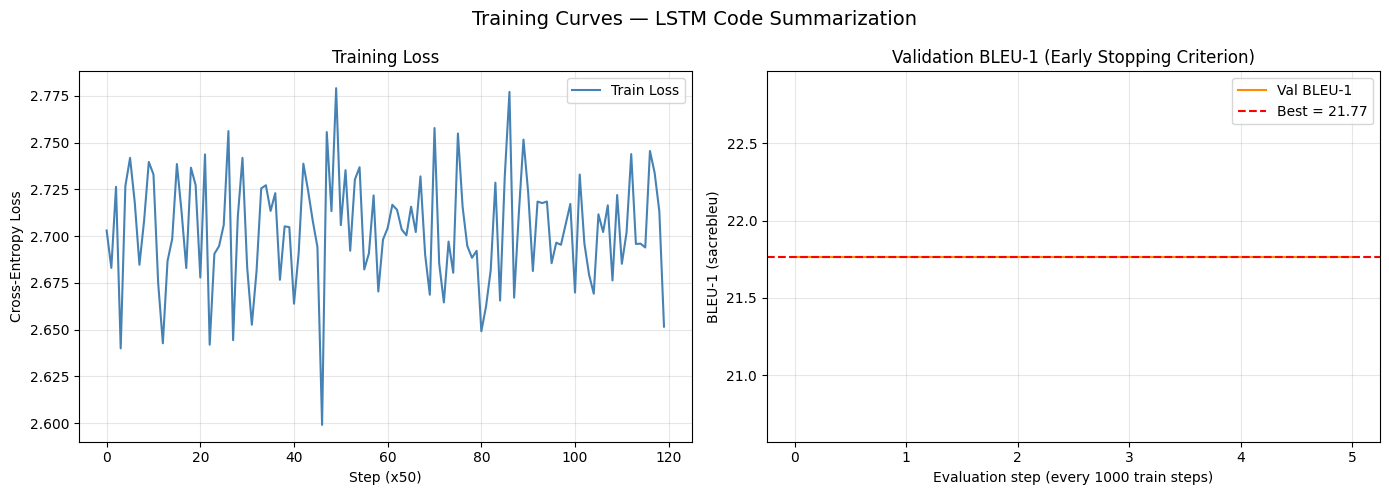

In [78]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel(f'Step (x{LOG_STEPS})')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(val_bleu1s, label='Val BLEU-1', color='darkorange')
ax2.axhline(best_bleu1, linestyle='--', color='red', label=f'Best = {best_bleu1:.2f}')
ax2.set_title('Validation BLEU-1 (Early Stopping Criterion)')
ax2.set_xlabel(f'Evaluation step (every {EVAL_STEPS} train steps)')
ax2.set_ylabel('BLEU-1 (sacrebleu)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training Curves — LSTM Code Summarization', fontsize=14)
plt.tight_layout()
os.makedirs('predictions', exist_ok=True)
plt.savefig('predictions/training_curves.png', dpi=150)
plt.show()
